#Задание 1:
Необходимо создать класс, который выполнял бы метод градиентного спуска. На вход для него задается функция, градиент и начальная точка (задается двумерным массивом). Градиент рассчитывается заранее, перед тем, как подать его в виде параметра в класс.  Если начальная точка не задана, то она выбирается случайным образом.
Размеры осей заданы от -20 до 20 с шагов в 0,25 единиц. Размеры осей задаются по умолчанию, но должны иметь параметры, чтобы пользователь мог задать их самостоятельно.
Класс должен выполнять метод градиентного спуска и проверять:
Не вылетела ли точка за границы;
Точка действительно оказалась в минимуме.
Как осуществить данную проверка - каждый решает сам.
Необходимо будет нарисовать график.

Моя функция:

$$f(x,y) = x^2/800 - y^2/800 + 1/2$$




In [3]:
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt # для рисования графиков
from random import uniform
from matplotlib import cm
import pandas
import numpy
import math

In [4]:
def f(x,y):
  return (x**2/800 - y**2/800 + 1/2)

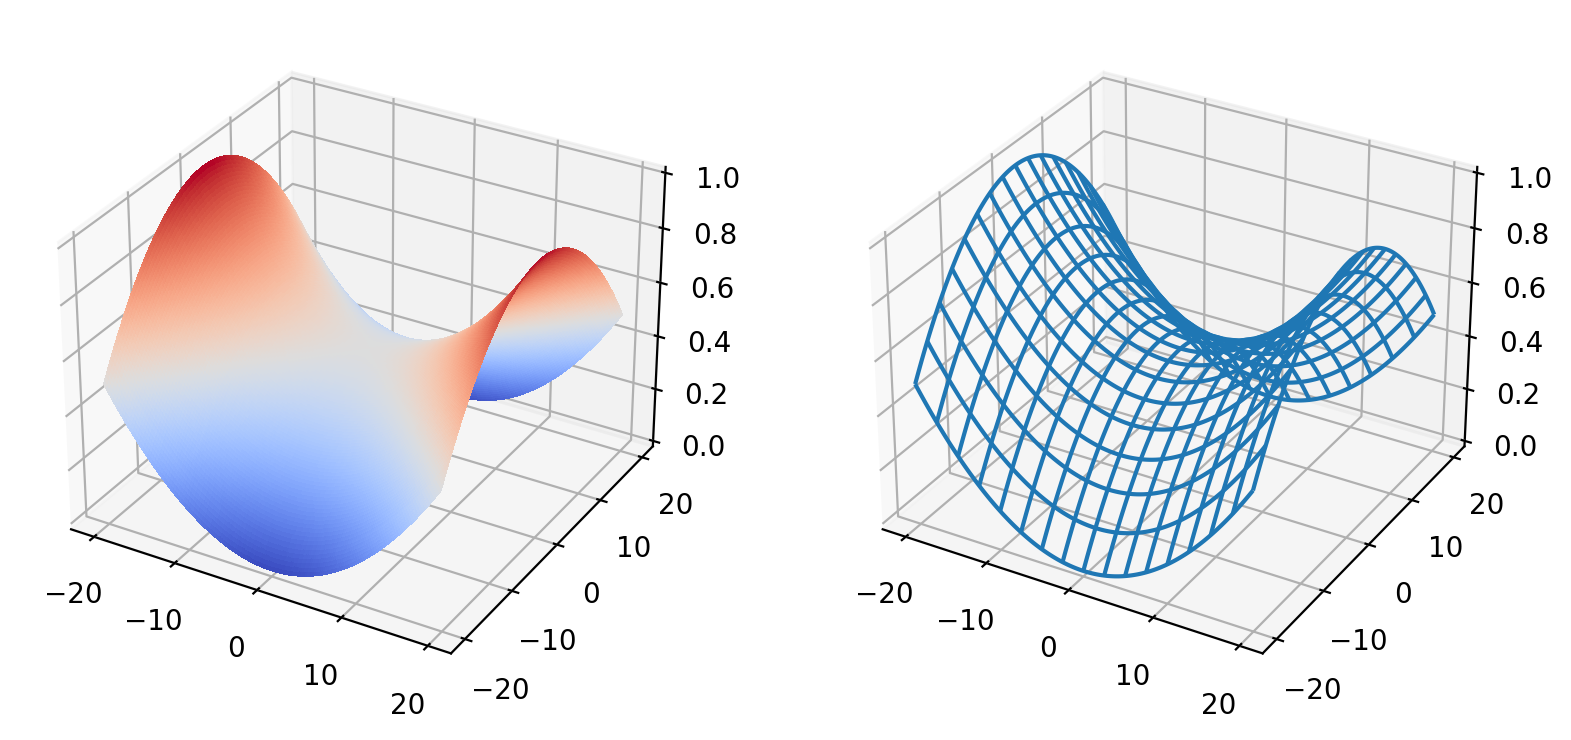

In [ ]:
fig = plt.figure(figsize=plt.figaspect(0.5), dpi=200)

ax = fig.add_subplot(1, 2, 1, projection='3d')
X = numpy.arange(-20, 20, 0.25)
Y = numpy.arange(-20, 20, 0.25)
X, Y = numpy.meshgrid(X, Y)
Z = f(X,Y)
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax = fig.add_subplot(1, 2, 2, projection='3d')
ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

In [5]:
# Расчет градиента для моей функции
def calculate_gradient(x,y):
  grad_x = x / 400
  grad_y = -y / 400
  return (grad_x, grad_y)
  #return (2*x**(2-1)/800), (- 2*y**(2-1)/800)

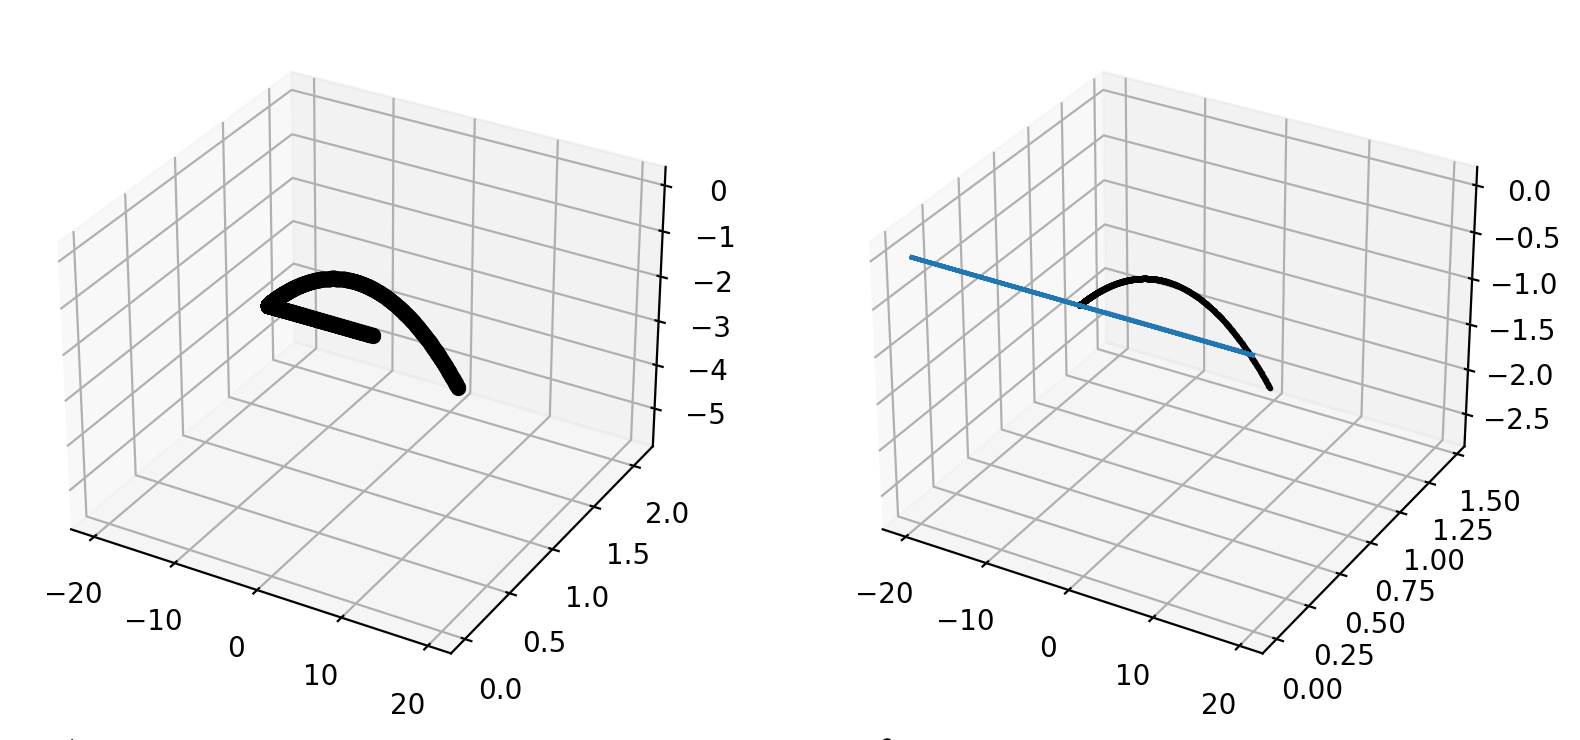

In [ ]:
fig = plt.figure(figsize=plt.figaspect(0.5), dpi=200)

ax = fig.add_subplot(1, 2, 1, projection='3d')
X = numpy.arange(-20, 20, 0.25)
Y = numpy.arange(-20, 20, 0.25)
X, Y = numpy.meshgrid(X, Y)
Z = f(X,Y)
x_0 = 12
y_0 = 3
for i in numpy.arange(10000):
    z_0 = f(x_0,y_0)
    x_1 = x_0 - calculate_gradient(x_0,y_0)[0]
    y_1 = y_0 - calculate_gradient(x_0,y_0)[1]
    z_1 = f(x_1,y_1)
    ax.plot([x_0, x_1], [y_0, y_1], [z_0, z_1], color='black',zorder=1)
    ax.scatter( x_1,  y_1,  z_1, color='black',zorder=1)
    x_0, y_0 = x_1, y_1
ax.plot_surface(X, Y, Z, rstride=1, cstride=1, cmap=cm.coolwarm, linewidth=0, antialiased=False)
ax = fig.add_subplot(1, 2, 2, projection='3d')
for i in numpy.arange(10000):
    z_0 = f(x_0,y_0)
    x_1 = x_0 - calculate_gradient(x_0,y_0)[0]
    y_1 = y_0 - calculate_gradient(x_0,y_0)[1]
    z_1 = f(x_1,y_1)
    ax.plot([x_0, x_1], [y_0, y_1], [z_0, z_1], color='black',zorder=1)
    ax.scatter( x_1,  y_1,  z_1, color='black',zorder=1,s=1)
    x_0, y_0 = x_1, y_1

ax.plot_wireframe(X, Y, Z, rstride=10, cstride=10)

#Задание 2:
Расширить класс с помощью модификаций метода градиентного спуска (или можно сделать три дополнительных класса, которые будут выполнять эти модификации, на ваше усмотрение):
**Adam;
AdaGrad;
метод Нестерова.**
В выводе написать с какой модификацией ваша функция работает лучше всех.

https://vk.com/@stranger.blog-metody-gradientnogo-spuska-v-obuchenii-neironnyh-setei


In [6]:
# Класс, реализующий метод градиентного спуска
class Gradient:
   # Инициализация
   def __init__(self, function, gradient, starting_point = None, x_axis = (-20, 20), y_axis = (-20, 20), step_size = 0.25):
      self.function = function
      self.gradient = gradient
      self.starting_point = starting_point
      self.x_axis = x_axis
      self.y_axis = y_axis
      self.step_size = step_size
      # Если начальной точки нет, то она выбирается случайным образом
      if starting_point is None:
         self.starting_point = [uniform(x_axis[0], x_axis[1]), uniform(y_axis[0], y_axis[1])]
         self.current_point = self.starting_point
      else:
         self.starting_point = starting_point # Иначе стартовая точка - точка, которая задана
         self.current_point = self.starting_point
      self.path = []  # Инициализируем пустым списком путь
      if self.starting_point is not None:
         self.path.append(self.starting_point)

  # Основной блок fit() - классические градиент
   def fit_classic(self, iterations = 100, tolerance = 1e-5):
      for _ in range(iterations):
         # Проверка на то, а точно ли current_point не определен
         if self.current_point is not None:
            # Вычисление градиента в текущей точке
            grad_x, grad_y = self.gradient(self.current_point[0], self.current_point[1])
            # Обновление текущей точки
            new_x = self.current_point[0] - self.step_size * grad_x # Обновляем координату по х
            new_y = self.current_point[1] - self.step_size * grad_y # Обновляем координату по у
            self.current_point = [new_x, new_y] # Обновленная точка
            # Проверка на выход за границы
            if not (self.x_axis[0] <= self.current_point[0] <= self.x_axis[1] and self.y_axis[0] <= self.current_point[1] <= self.y_axis[1]):
               #print("Точка вышла за границы")
               # Проекция точки обратно на границу
               self.current_point[0] = max(self.x_axis[0], min(self.current_point[0], self.x_axis[1]))
               self.current_point[1] = max(self.y_axis[0], min(self.current_point[1], self.y_axis[1]))
            # Проверка на сходимость
            if numpy.sqrt(grad_x**2 + grad_y**2) < tolerance:
               print("Сходимость достигнута")
               break
         # Добавление текущей точки в путь
            self.path.append(self.current_point)
         else:
            print("Ошибка: self.current_point не определен.")
            break  # Выход из цикла
      return self.current_point

   # Основной блок fit() - градиент Нестерова
   def fit_nesterov(self, iterations = 100, tolerance = 1e-5, momentum = 0.8):
      self.momentum = momentum
      velocity = [0, 0]
      for _ in range(iterations):
         # Проверка на то, а точно ли current_point не определен
         if self.current_point is not None:
            # Вычисление градиента в текущей точке
            grad_x, grad_y = self.gradient(self.current_point[0], self.current_point[1])
            # Обновление импульса
            velocity = [self.momentum * v - self.step_size * g for v, g in zip(velocity, [grad_x, grad_y])]
            # Обновление текущей точки
            new_x = self.current_point[0] + velocity[0] # Обновляем координату по х, применяем испульс
            new_y = self.current_point[1] + velocity[1] # Обновляем координату по у, применяем испульс
            self.current_point = [new_x, new_y] # Обновленная точка
            # Проверка на выход за границы
            if not (self.x_axis[0] <= self.current_point[0] <= self.x_axis[1] and self.y_axis[0] <= self.current_point[1] <= self.y_axis[1]):
               #print("Точка вышла за границы")
               # Проекция точки обратно на границу
               self.current_point[0] = max(self.x_axis[0], min(self.current_point[0], self.x_axis[1]))
               self.current_point[1] = max(self.y_axis[0], min(self.current_point[1], self.y_axis[1]))
            # Проверка на сходимость
            if numpy.sqrt(grad_x**2 + grad_y**2) < tolerance:
               print("Сходимость достигнута")
               break
            # Добавление текущей точки в путь
            self.path.append(self.current_point)
         else:
            print("Ошибка: self.current_point не определен.")
            break  # Выход из цикла

      return self.current_point


   # Основной блок fit() - градиент AdaGrad
   def fit_adagrad(self, iterations = 100, tolerance = 1e-5, epsilon = 1e-8):
      self.epsilon = epsilon
      G = [0, 0] # Инициализация накопленной суммы квадратов градиентов
      for _ in range(iterations):
         # Проверка на то, а точно ли current_point не определен
         if self.current_point is not None:
            # Вычисление градиента в текущей точке
            grad_x, grad_y = self.gradient(self.current_point[0], self.current_point[1])
            # Обновление G
            G = [G_i + g_i ** 2 for G_i, g_i in zip(G, [grad_x, grad_y])]
            # Обновление текущей точки
            new_x = self.current_point[0] - self.step_size * grad_x / (numpy.sqrt(G[0] + self.epsilon)) # Обновляем координату по х
            new_y = self.current_point[1] - self.step_size * grad_y / (numpy.sqrt(G[1] + self.epsilon)) # Обновляем координату по у
            self.current_point = [new_x, new_y] # Обновленная точка
            # Проверка на выход за границы
            if not (self.x_axis[0] <= self.current_point[0] <= self.x_axis[1] and self.y_axis[0] <= self.current_point[1] <= self.y_axis[1]):
               #print("Точка вышла за границы")
               # Проекция точки обратно на границу
               self.current_point[0] = max(self.x_axis[0], min(self.current_point[0], self.x_axis[1]))
               self.current_point[1] = max(self.y_axis[0], min(self.current_point[1], self.y_axis[1]))
            # Проверка на сходимость
            if numpy.sqrt(grad_x**2 + grad_y**2) < tolerance:
               print("Сходимость достигнута")
               break
            # Добавление текущей точки в путь
            self.path.append(self.current_point)
         else:
            print("Ошибка: self.current_point не определен.")
            break  # Выход из цикла
      return self.current_point


   # Основной блок fit() - градиент Adam
   def fit_adam(self, iterations = 100, tolerance = 1e-5, epsilon = 1e-7, beta1 = 0.9, beta2 = 0.999):
      self.beta1 = beta1
      self.beta2 = beta2
      self.epsilon = epsilon
      m = [0, 0] # Инициализация первого момента
      v = [0, 0] # Инициализация второго момента
      t = 0 # Счетчик шагов
      for _ in range(iterations):
         # Проверка на то, а точно ли current_point не определен
         if self.current_point is not None:
            # Вычисление градиента в текущей точке
            grad_x, grad_y = self.gradient(self.current_point[0], self.current_point[1])
            t += 1
            # Обновление моментов
            m = [self.beta1 * m_i + (1 - self.beta1) * g_i for m_i, g_i in zip(m, [grad_x, grad_y])]
            v = [self.beta2 * v_i + (1 - self.beta2) * g_i ** 2 for v_i, g_i in zip(v, [grad_x, grad_y])]
            # Коррекция моментов
            m_hat = [m_i / (1 - self.beta1**t) for m_i in m]
            v_hat = [v_i / (1 - self.beta2**t) for v_i in v]
            # Обновление текущей точки
            new_x = max(min(self.current_point[0] - self.step_size * m_hat[0]
                           / (numpy.sqrt(v_hat[0]) + self.epsilon), self.x_axis[1]), self.x_axis[0]) # Обновляем координату по х
            # Обновляем координату по у
            new_y = max(min(self.current_point[1] - self.step_size * m_hat[1]
                           / (numpy.sqrt(v_hat[1]) + self.epsilon), self.x_axis[1]), self.x_axis[0])
            self.current_point = [new_x, new_y] # Обновленная точка
            # Проверка на выход за границы
            if not (self.x_axis[0] <= self.current_point[0] <= self.x_axis[1] and self.y_axis[0] <= self.current_point[1] <= self.y_axis[1]):
               #print("Точка вышла за границы")
               # Проекция точки обратно на границу
               self.current_point[0] = max(self.x_axis[0], min(self.current_point[0], self.x_axis[1]))
               self.current_point[1] = max(self.y_axis[0], min(self.current_point[1], self.y_axis[1]))
            # Проверка на сходимость
            if numpy.sqrt(grad_x**2 + grad_y**2) < tolerance:
               print("Сходимость достигнута")
               break
            # Добавление текущей точки в путь
            self.path.append(self.current_point)
         else:
            print("Ошибка: self.current_point не определен.")
            break  # Выход из цикла
      return self.current_point


  # Функция которая будет рисовать график
   def build_3d_graph(self):
      # Создание сетки для графика
      x = numpy.arange(self.x_axis[1], self.x_axis[0], -self.step_size)
      y = numpy.arange(self.y_axis[1], self.y_axis[0], -self.step_size)
      #print(f"x: {x};\ny: {y};")
      X, Y = numpy.meshgrid(x, y)
      Z = self.function(X, Y)
      # Построение 3D-графика
      fig = plt.figure()
      ax = fig.add_subplot(projection='3d')
      #print(f"X: {X};\nY: {Y};\nZ: {Z}")
      ax.plot_surface(X, Y, Z, cmap=cm.viridis, alpha = 0.5)
      # Построение пути градиентного спуска
      path_x, path_y = zip(*self.path)
      ax.plot(path_x, path_y, [self.function(*point) for point in self.path],
              color='red', label='Gradient Descent Path')
      # Добавление меток и легенды
      ax.set_xlabel('x')
      ax.set_ylabel('y')
      ax.set_zlabel('z')
      ax.legend()
      plt.show()

Точка минимума - classical: [-14.090920611493075, -5.322368384360721]


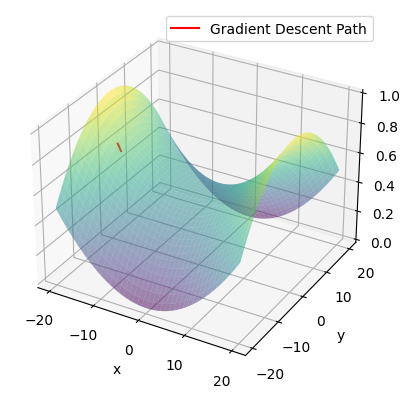

Точка минимума - Nesterov: [-11.067549225398249, -6.72352340320493]


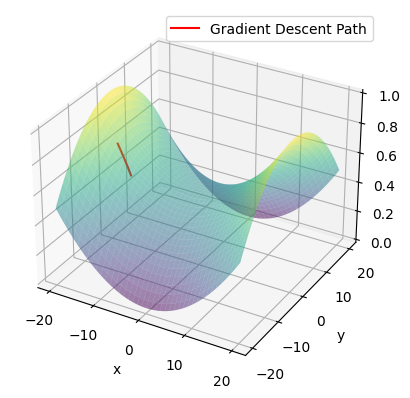

Точка минимума - AdaGrad: [-10.643473161663865, -10.255862922808266]


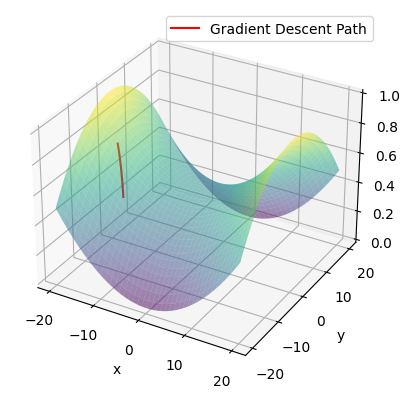

Точка минимума - Adam: [-0.28301082206605827, -20]


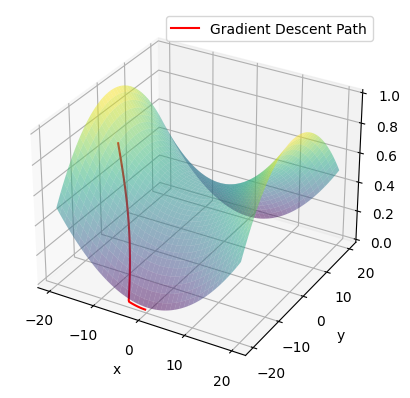

Наилучший алгоритм - Adam


In [7]:
results_dictionary = dict() # Словарь результатов
best_value = numpy.inf
best_result = None

# Используем наш класс
gradient_descent = Gradient(f, calculate_gradient, starting_point = [-15, -5]) # Создание экземпляра модели - классический градиент
final_point = gradient_descent.fit_classic(iterations = 100) # Обучение модели
results_dictionary['Classic'] = final_point
print("Точка минимума - classical:", final_point)
gradient_descent.build_3d_graph()

# Используем наш класс
gradient_descent = Gradient(f, calculate_gradient, starting_point = [-15, -5]) # Создание экземпляра модели - градиент Нестерова
final_point = gradient_descent.fit_nesterov(iterations = 100, momentum = 0.8) # Обучение модели. Теперь мы задаем импульс
results_dictionary['Nesterov'] = final_point
print("Точка минимума - Nesterov:", final_point)
gradient_descent.build_3d_graph()

# Используем наш класс
gradient_descent = Gradient(f, calculate_gradient, starting_point = [-15, -5]) # Создание экземпляра модели - градиент AdaGrad
final_point = gradient_descent.fit_adagrad(iterations = 100) # Обучение модели. Теперь мы задаем импульс
results_dictionary['AdaGrad'] = final_point
print("Точка минимума - AdaGrad:", final_point)
gradient_descent.build_3d_graph()

# Используем наш класс
gradient_descent = Gradient(f, calculate_gradient, starting_point = [-15, -5]) # Создание экземпляра модели - градиент Adam
final_point = gradient_descent.fit_adam(iterations = 100, beta1 = 0.9, beta2 = 0.999) # Обучение модели. Теперь мы задаем параметры для Адама
results_dictionary['Adam'] = final_point
print("Точка минимума - Adam:", final_point)
gradient_descent.build_3d_graph()

for algorithm, coordinates in zip(results_dictionary.keys(), results_dictionary.values()):
   value = f(coordinates[0], coordinates[1]) # подсчет значения функции по координатам найденного минимума
   if value < best_value: # Если значение функции меньше текущего лучшего результата, то меняем на новые данные
      best_result = algorithm
      best_value = value

print(f"Наилучший алгоритм - {best_result}")